In [ ]:
# Importing libraries
import pandas as pd
import numpy as np
import math
from itertools import combinations
from collections import Counter

In [ ]:
ratings = pd.read_csv("optimized_elo_2026.csv")

ELO_COL = "Pre_Tournament_Elo"
TEAM_COL = "Team"

elo = dict(zip(ratings[TEAM_COL], ratings[ELO_COL]))

groups = {
    'A': ["Mexico", "South Africa", "South Korea", "Czech Republic"],
    'B': ["Canada", "Switzerland", "Qatar", "Bosnia and Herzegovina"],
    'C': ["Brazil", "Morocco", "Haiti", "Scotland"],
    'D': ["United States", "Paraguay", "Australia", "Turkey"],
    'E': ["Germany", "Curaçao", "Ivory Coast", "Ecuador"],
    'F': ["Netherlands", "Japan", "Tunisia", "Sweden"],
    'G': ["Belgium", "Egypt", "Iran", "New Zealand"],
    'H': ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    'I': ["France", "Senegal", "Norway", "Iraq"],
    'J': ["Argentina", "Algeria", "Austria", "Jordan"],
    'K': ["Portugal", "Uzbekistan", "Colombia", "DR Congo"],
    'L': ["England", "Croatia", "Ghana", "Panama"]
}

# Validation
csv_teams = set(ratings["Team"])
group_teams = {team for group in groups.values() for team in group}

print("Teams in CSV but not groups:", sorted(csv_teams - group_teams))
print("Teams in groups but not CSV:", sorted(group_teams - csv_teams))

Teams in CSV but not groups: []
Teams in groups but not CSV: []


In [ ]:
def elo_prob(team_a, team_b):
    """Classic Elo expected score for team A."""
    diff = elo[team_a] - elo[team_b]
    return 1 / (1 + 10 ** (-diff / 400))


def match_probs(team_a, team_b):
    """
    Converts Elo into win/draw/loss probabilities.
    Draws are more likely when teams are close in strength.
    """
    p_a_no_draw = elo_prob(team_a, team_b)

    diff = abs(elo[team_a] - elo[team_b])
    p_draw = 0.18 + 0.12 * math.exp(-diff / 300)
    p_draw = min(max(p_draw, 0.16), 0.32)

    p_a_win = (1 - p_draw) * p_a_no_draw
    p_b_win = (1 - p_draw) * (1 - p_a_no_draw)

    return p_a_win, p_draw, p_b_win

In [ ]:
def simulate_score(outcome, rng):
    """Generate a plausible football scoreline."""
    if outcome == "draw":
        goals = rng.choice([0, 1, 2, 3], p=[0.26, 0.46, 0.22, 0.06])
        return int(goals), int(goals)

    loser_goals = rng.choice([0, 1, 2, 3], p=[0.48, 0.34, 0.14, 0.04])
    margin = rng.choice([1, 2, 3, 4], p=[0.56, 0.27, 0.12, 0.05])
    winner_goals = loser_goals + margin

    if outcome == "a":
        return int(winner_goals), int(loser_goals)
    else:
        return int(loser_goals), int(winner_goals)


def simulate_match(team_a, team_b, rng):
    p_a, p_draw, p_b = match_probs(team_a, team_b)

    outcome = rng.choice(["a", "draw", "b"], p=[p_a, p_draw, p_b])
    goals_a, goals_b = simulate_score(outcome, rng)

    return goals_a, goals_b

In [ ]:
def simulate_group(group_name, teams, rng):
    table = {
        team: {
            "Group": group_name,
            "Team": team,
            "Elo": elo[team],
            "MP": 0,
            "W": 0,
            "D": 0,
            "L": 0,
            "GF": 0,
            "GA": 0,
            "GD": 0,
            "Pts": 0,
        }
        for team in teams
    }

    for team_a, team_b in combinations(teams, 2):
        goals_a, goals_b = simulate_match(team_a, team_b, rng)

        table[team_a]["MP"] += 1
        table[team_b]["MP"] += 1

        table[team_a]["GF"] += goals_a
        table[team_a]["GA"] += goals_b
        table[team_b]["GF"] += goals_b
        table[team_b]["GA"] += goals_a

        if goals_a > goals_b:
            table[team_a]["W"] += 1
            table[team_b]["L"] += 1
            table[team_a]["Pts"] += 3
        elif goals_b > goals_a:
            table[team_b]["W"] += 1
            table[team_a]["L"] += 1
            table[team_b]["Pts"] += 3
        else:
            table[team_a]["D"] += 1
            table[team_b]["D"] += 1
            table[team_a]["Pts"] += 1
            table[team_b]["Pts"] += 1

    df = pd.DataFrame(table.values())
    df["GD"] = df["GF"] - df["GA"]

    df = df.sort_values(
        ["Pts", "GD", "GF", "Elo"],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)

    df["Pos"] = range(1, 5)
    return df


def simulate_group_stage(rng):
    all_groups = []

    for group_name, teams in groups.items():
        group_table = simulate_group(group_name, teams, rng)
        all_groups.append(group_table)

    return pd.concat(all_groups, ignore_index=True)

In [ ]:
def get_qualifiers(standings):
    top_two = standings[standings["Pos"] <= 2].copy()

    third_place = standings[standings["Pos"] == 3].copy()
    best_thirds = third_place.sort_values(
        ["Pts", "GD", "GF", "Elo"],
        ascending=[False, False, False, False]
    ).head(8)

    qualifiers = pd.concat([top_two, best_thirds], ignore_index=True)

    qualifiers["FinishBucket"] = qualifiers["Pos"].map({
        1: 1,
        2: 2,
        3: 3
    })

    qualifiers = qualifiers.sort_values(
        ["FinishBucket", "Pts", "GD", "GF", "Elo"],
        ascending=[True, False, False, False, False]
    ).reset_index(drop=True)

    qualifiers["Seed"] = range(1, len(qualifiers) + 1)

    return qualifiers

In [ ]:
BRACKET_SEED_PAIRS = [
    (1, 32), (16, 17), (8, 25), (9, 24),
    (4, 29), (13, 20), (5, 28), (12, 21),
    (2, 31), (15, 18), (7, 26), (10, 23),
    (3, 30), (14, 19), (6, 27), (11, 22),
]


def make_round_of_32(qualifiers):
    seed_to_team = dict(zip(qualifiers["Seed"], qualifiers["Team"]))
    return [(seed_to_team[a], seed_to_team[b]) for a, b in BRACKET_SEED_PAIRS]


def knockout_winner(team_a, team_b, rng):
    p_a = elo_prob(team_a, team_b)
    return team_a if rng.random() < p_a else team_b


def play_bracket(round_of_32, rng):
    rounds = {
        "Round of 32": round_of_32
    }

    current = round_of_32
    round_names = ["Round of 32", "Round of 16", "Quarterfinals", "Semifinals", "Final"]
    bracket_rows = []

    for round_name in round_names:
        winners = []

        for team_a, team_b in current:
            p_a = elo_prob(team_a, team_b)
            winner = knockout_winner(team_a, team_b, rng)

            bracket_rows.append({
                "Round": round_name,
                "Team A": team_a,
                "Team B": team_b,
                "P(A advances)": p_a,
                "P(B advances)": 1 - p_a,
                "Winner": winner
            })

            winners.append(winner)

        if len(winners) == 1:
            return winners[0], pd.DataFrame(bracket_rows)

        current = list(zip(winners[::2], winners[1::2]))

In [ ]:
def simulate_tournament(seed=42):
    rng = np.random.default_rng(seed)

    standings = simulate_group_stage(rng)
    qualifiers = get_qualifiers(standings)
    round_of_32 = make_round_of_32(qualifiers)
    champion, bracket = play_bracket(round_of_32, rng)

    return standings, qualifiers, bracket, champion


standings, qualifiers, bracket, champion = simulate_tournament(seed=7)

print("Champion:", champion)
display(standings)
display(qualifiers)
display(bracket)

Champion: Argentina


,Group,Team,Elo,MP,W,D,L,GF,GA,GD,Pts,Pos
0,A,Mexico,1913.878809,3,3,0,0,11,4,7,9,1
1,A,South Korea,1855.532907,3,1,1,1,2,4,-2,4,2
2,A,Czech Republic,1787.274019,3,0,2,1,4,6,-2,2,3
3,A,South Africa,1640.581702,3,0,1,2,3,6,-3,1,4
4,B,Switzerland,1932.167055,3,2,0,1,6,4,2,6,1
5,B,Bosnia and Herzegovina,1642.065523,3,1,2,0,2,1,1,5,2
6,B,Qatar,1544.989612,3,1,1,1,2,2,0,4,3
7,B,Canada,1880.462505,3,0,1,2,1,4,-3,1,4
8,C,Brazil,2063.820766,3,2,1,0,3,0,3,7,1
9,C,Scotland,1781.369604,3,1,1,1,4,3,1,4,2


,Group,Team,Elo,MP,W,D,L,GF,GA,GD,Pts,Pos,FinishBucket,Seed
0,A,Mexico,1913.878809,3,3,0,0,11,4,7,9,1,1,1
1,G,Belgium,1948.080585,3,3,0,0,10,3,7,9,1,1,2
2,L,Croatia,1982.329371,3,3,0,0,6,0,6,9,1,1,3
3,F,Japan,1983.047226,3,3,0,0,6,1,5,9,1,1,4
4,H,Spain,2166.134956,3,3,0,0,6,2,4,9,1,1,5
5,E,Ecuador,1987.863760,3,3,0,0,5,2,3,9,1,1,6
6,I,France,2119.621410,3,2,1,0,8,4,4,7,1,1,7
7,C,Brazil,2063.820766,3,2,1,0,3,0,3,7,1,1,8
8,K,Portugal,2031.077085,3,2,1,0,6,4,2,7,1,1,9
9,J,Austria,1892.888924,3,2,1,0,5,3,2,7,1,1,10


,Round,Team A,Team B,P(A advances),P(B advances),Winner
0,Round of 32,Mexico,Senegal,0.491590,0.508410,Senegal
1,Round of 32,England,Netherlands,0.531415,0.468585,England
2,Round of 32,Brazil,Turkey,0.699201,0.300799,Brazil
3,Round of 32,Portugal,South Korea,0.733121,0.266879,Portugal
4,Round of 32,Japan,Tunisia,0.775122,0.224878,Tunisia
5,Round of 32,Germany,Bosnia and Herzegovina,0.876390,0.123610,Bosnia and Herzegovina
6,Round of 32,Spain,Uzbekistan,0.885428,0.114572,Spain
7,Round of 32,United States,Scotland,0.533578,0.466422,United States
8,Round of 32,Belgium,Panama,0.690471,0.309529,Belgium
9,Round of 32,Iran,Colombia,0.281032,0.718968,Colombia


In [ ]:
def run_monte_carlo(n_sims=1000, seed=42):
    rng = np.random.default_rng(seed)
    champions = Counter()

    for _ in range(n_sims):
        standings = simulate_group_stage(rng)
        qualifiers = get_qualifiers(standings)
        round_of_32 = make_round_of_32(qualifiers)
        champion, bracket = play_bracket(round_of_32, rng)

        champions[champion] += 1

    champion_probs = pd.DataFrame([
        {
            "Team": team,
            "Champion Probability": count / n_sims
        }
        for team, count in champions.items()
    ])

    champion_probs = champion_probs.sort_values(
        "Champion Probability",
        ascending=False
    ).reset_index(drop=True)

    return champion_probs


champion_probs = run_monte_carlo(n_sims=1000, seed=7)
display(champion_probs.head(15))

,Team,Champion Probability
0,Spain,0.217
1,Argentina,0.212
2,France,0.145
3,Portugal,0.054
4,Colombia,0.053
5,England,0.047
6,Brazil,0.043
7,Netherlands,0.038
8,Japan,0.023
9,Ecuador,0.023


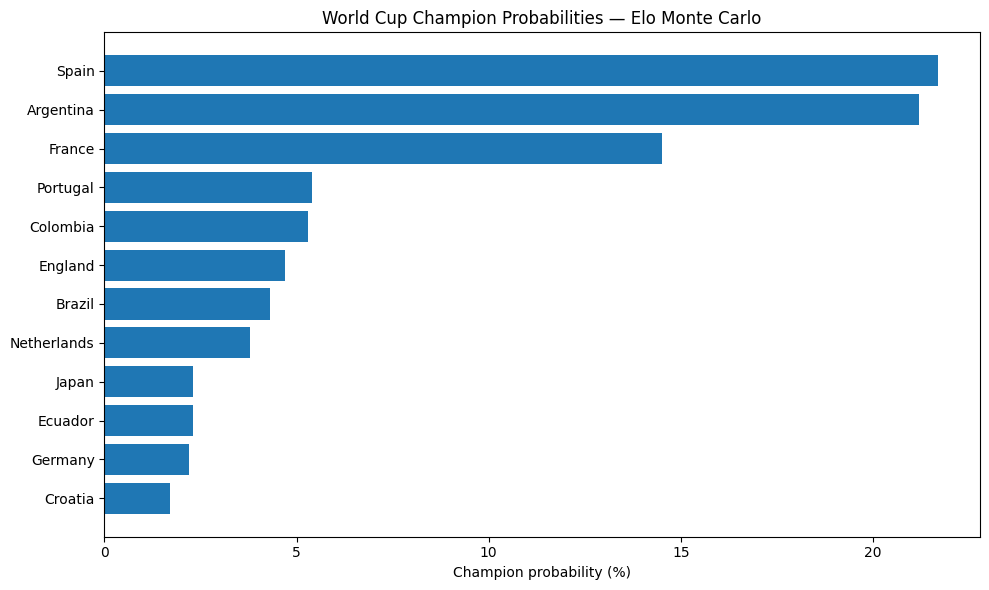

In [ ]:
import matplotlib.pyplot as plt

top = champion_probs.head(12).copy()

plt.figure(figsize=(10, 6))
plt.barh(top["Team"][::-1], (top["Champion Probability"] * 100)[::-1])
plt.xlabel("Champion probability (%)")
plt.title("World Cup Champion Probabilities — Elo Monte Carlo")
plt.tight_layout()
plt.show()